# BVP-TPV

                  mean        std  count
state                                   
baseline    898.751773  40.576654    282
meditation  908.583333  44.816684     84
stress      953.796053  28.067879    152
ANOVA p = 5.1589494345782756e-39


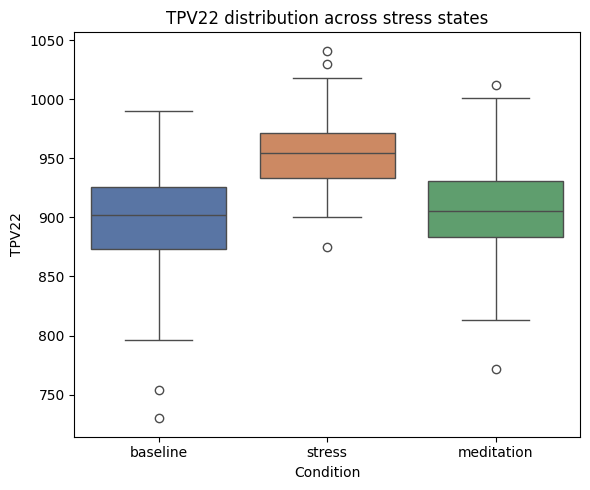

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal

# load
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BP/TPV-csv/noQC.csv")

# 상태 이름 정리
df["state"] = df["label_major"].map({
    1: "baseline",
    2: "stress",
    4: "meditation"
})

# TPV22만 사용
data = df[["subject", "state", "TPV22"]].dropna()

# -------------------------
# Mean ± STD 계산
# -------------------------
summary = data.groupby("state")["TPV22"].agg(["mean","std","count"])
print(summary)

# -------------------------
# p-value (ANOVA)
# -------------------------
b = data[data.state=="baseline"]["TPV22"]
s = data[data.state=="stress"]["TPV22"]
m = data[data.state=="meditation"]["TPV22"]

anova = f_oneway(b,s,m)
kruskal_test = kruskal(b,s,m)

print("ANOVA p =", anova.pvalue)

# -------------------------
# Figure
# -------------------------
plt.figure(figsize=(6,5))

sns.boxplot(
    x="state",
    y="TPV22",
    data=data,
    palette=["#4C72B0","#DD8452","#55A868"]
)

plt.xlabel("Condition")
plt.ylabel("TPV22")
plt.title("TPV22 distribution across stress states")

plt.tight_layout()
plt.show()


Feature: TPV9
                mean       std  count
state                                
baseline    0.005509  0.001327    282
meditation  0.005712  0.001484     84
stress      0.006910  0.001663    152
ANOVA p = 1.9180135625324544e-19


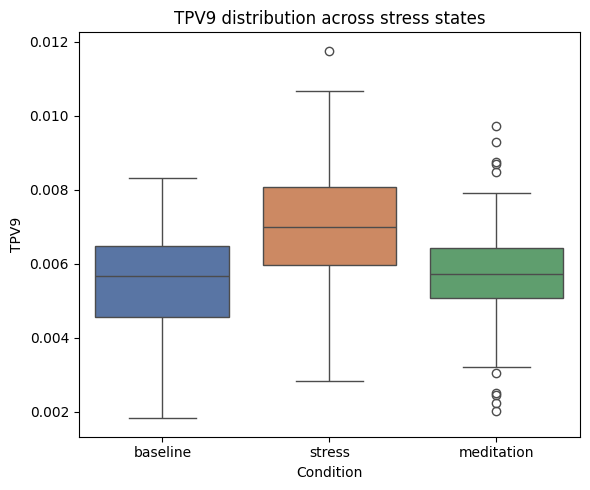


Feature: TPV4
                mean       std  count
state                                
baseline    0.006494  0.000935    282
meditation  0.006259  0.000939     84
stress      0.007397  0.001036    152
ANOVA p = 3.1329384049085664e-22


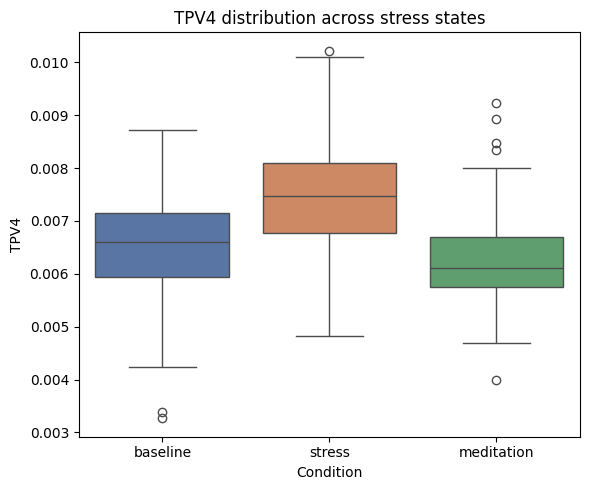


Feature: TPV2
                mean       std  count
state                                
baseline    0.041726  0.005720    282
meditation  0.038526  0.005595     84
stress      0.046419  0.004813    152
ANOVA p = 1.045838286358844e-25


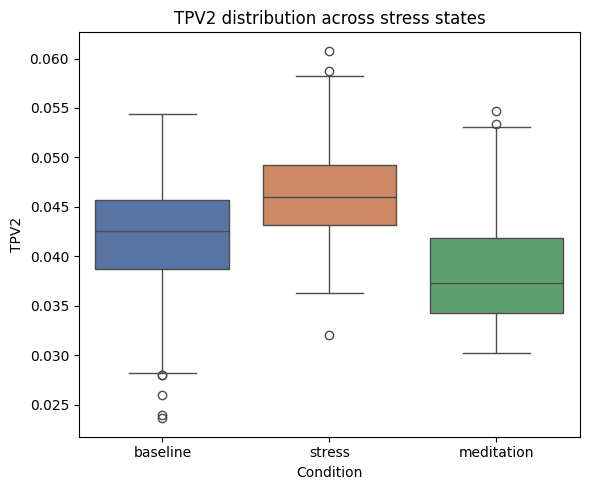


Feature: TPV0
                mean       std  count
state                                
baseline    0.035232  0.004924    282
meditation  0.032267  0.004852     84
stress      0.039022  0.003930    152
ANOVA p = 3.398801154818963e-25


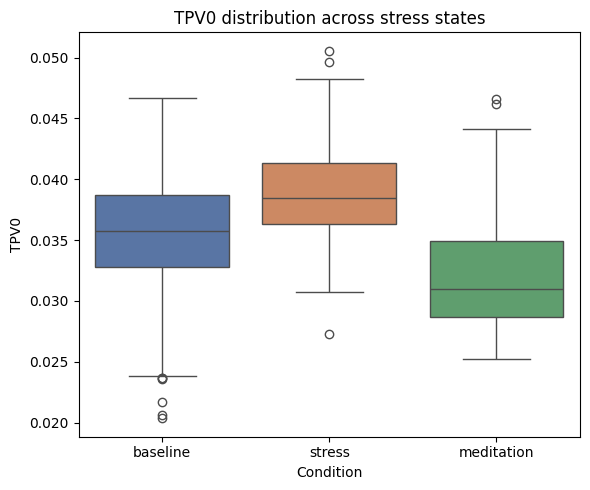


Feature: TPV28
                mean       std  count
state                                
baseline    0.008723  0.001402    282
meditation  0.007907  0.001354     84
stress      0.009519  0.001310    152
ANOVA p = 1.3582131355677366e-16


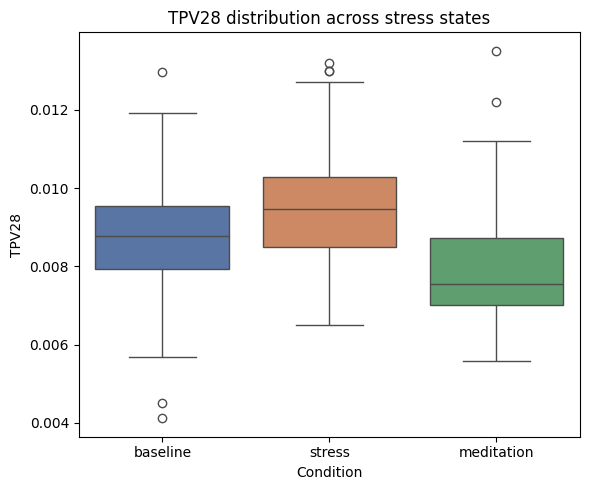


Feature: TPV8
                mean       std  count
state                                
baseline    0.002609  0.000695    282
meditation  0.002982  0.000859     84
stress      0.003303  0.000925    152
ANOVA p = 2.6972815266934495e-16


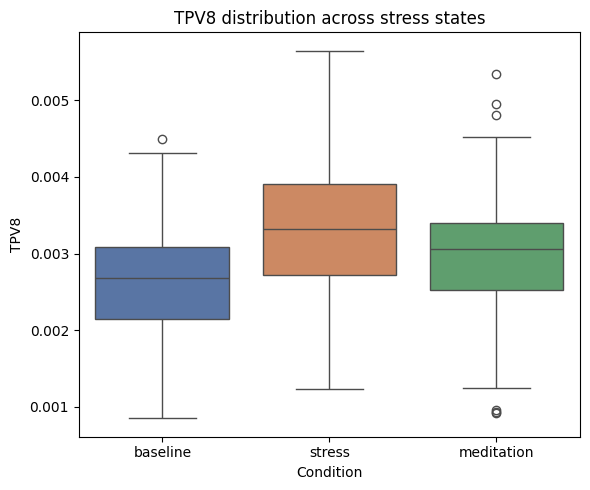


Feature: TPV19
                mean       std  count
state                                
baseline    0.021116  0.005777    282
meditation  0.023128  0.006577     84
stress      0.025585  0.007083    152
ANOVA p = 4.757507793518931e-11


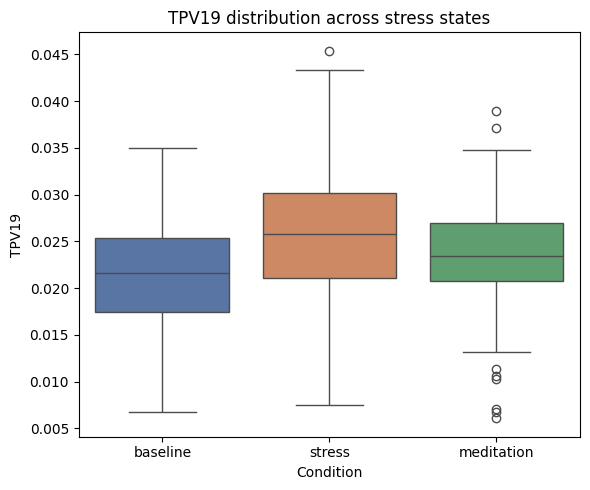


Feature: TPV14
                mean       std  count
state                                
baseline    0.017533  0.004766    282
meditation  0.018987  0.005328     84
stress      0.020980  0.005769    152
ANOVA p = 6.58164829521382e-10


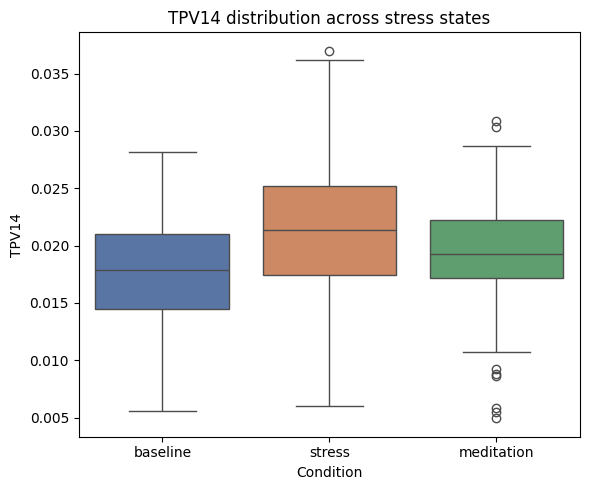


Feature: TPV26
                mean       std  count
state                                
baseline    5.839055  0.263056    282
meditation  5.965814  0.305811     84
stress      6.002106  0.255423    152
ANOVA p = 2.434152646218849e-09


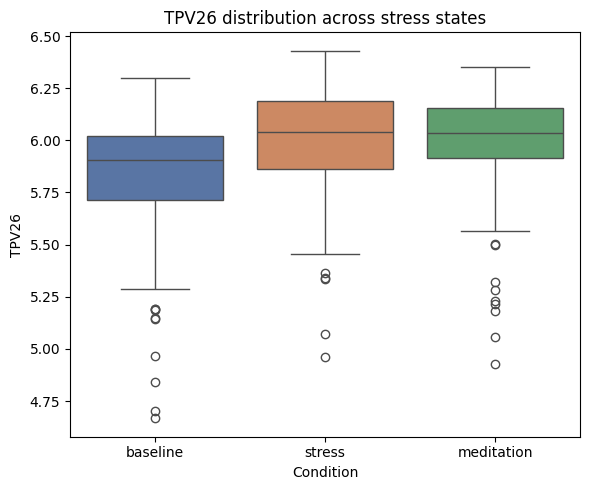


Feature: TPV11
                  mean        std  count
state                                   
baseline     95.477414  83.731069    282
meditation  115.184196  98.119935     84
stress       76.029079  78.717798    152
ANOVA p = 0.0025629139879606655


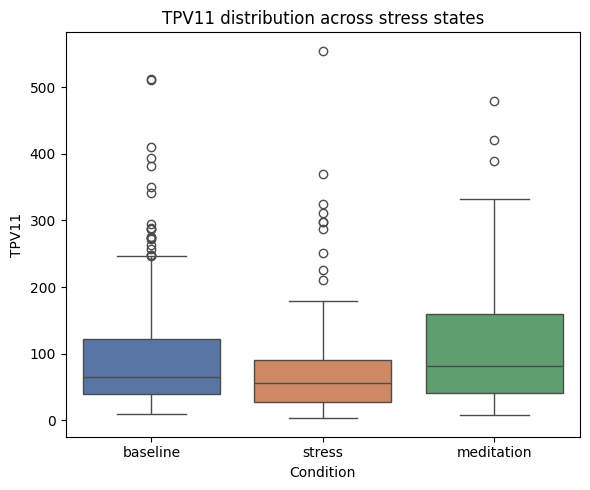


===== Statistical Test Summary =====
  feature       anova_p
0    TPV9  1.918014e-19
1    TPV4  3.132938e-22
2    TPV2  1.045838e-25
3    TPV0  3.398801e-25
4   TPV28  1.358213e-16
5    TPV8  2.697282e-16
6   TPV19  4.757508e-11
7   TPV14  6.581648e-10
8   TPV26  2.434153e-09
9   TPV11  2.562914e-03


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

# load
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BP/TPV-csv/noQC.csv")

# 상태 이름 정리
df["state"] = df["label_major"].map({
    1: "baseline",
    2: "stress",
    4: "meditation"
})

# 분석할 TPV feature 리스트
tpv_features = [
    'TPV9', 'TPV4', 'TPV2', 'TPV0', 'TPV28',
    'TPV8', 'TPV19', 'TPV14', 'TPV26', 'TPV11'
]

results = []

for feature in tpv_features:

    print("\n==============================")
    print(f"Feature: {feature}")
    print("==============================")

    data = df[["subject", "state", feature]].dropna()

    # mean ± std
    summary = data.groupby("state")[feature].agg(["mean","std","count"])
    print(summary)

    # 그룹 분리
    b = data[data.state=="baseline"][feature]
    s = data[data.state=="stress"][feature]
    m = data[data.state=="meditation"][feature]

    # 통계검정
    anova = f_oneway(b,s,m)

    print("ANOVA p =", anova.pvalue)

    # 결과 저장
    results.append({
        "feature": feature,
        "anova_p": anova.pvalue,
    })

    # figure
    plt.figure(figsize=(6,5))

    sns.boxplot(
        x="state",
        y=feature,
        data=data,
        palette=["#4C72B0","#DD8452","#55A868"]
    )

    plt.xlabel("Condition")
    plt.ylabel(feature)
    plt.title(f"{feature} distribution across stress states")

    plt.tight_layout()
    plt.show()

# 결과 테이블
results_df = pd.DataFrame(results)

print("\n===== Statistical Test Summary =====")
print(results_df)

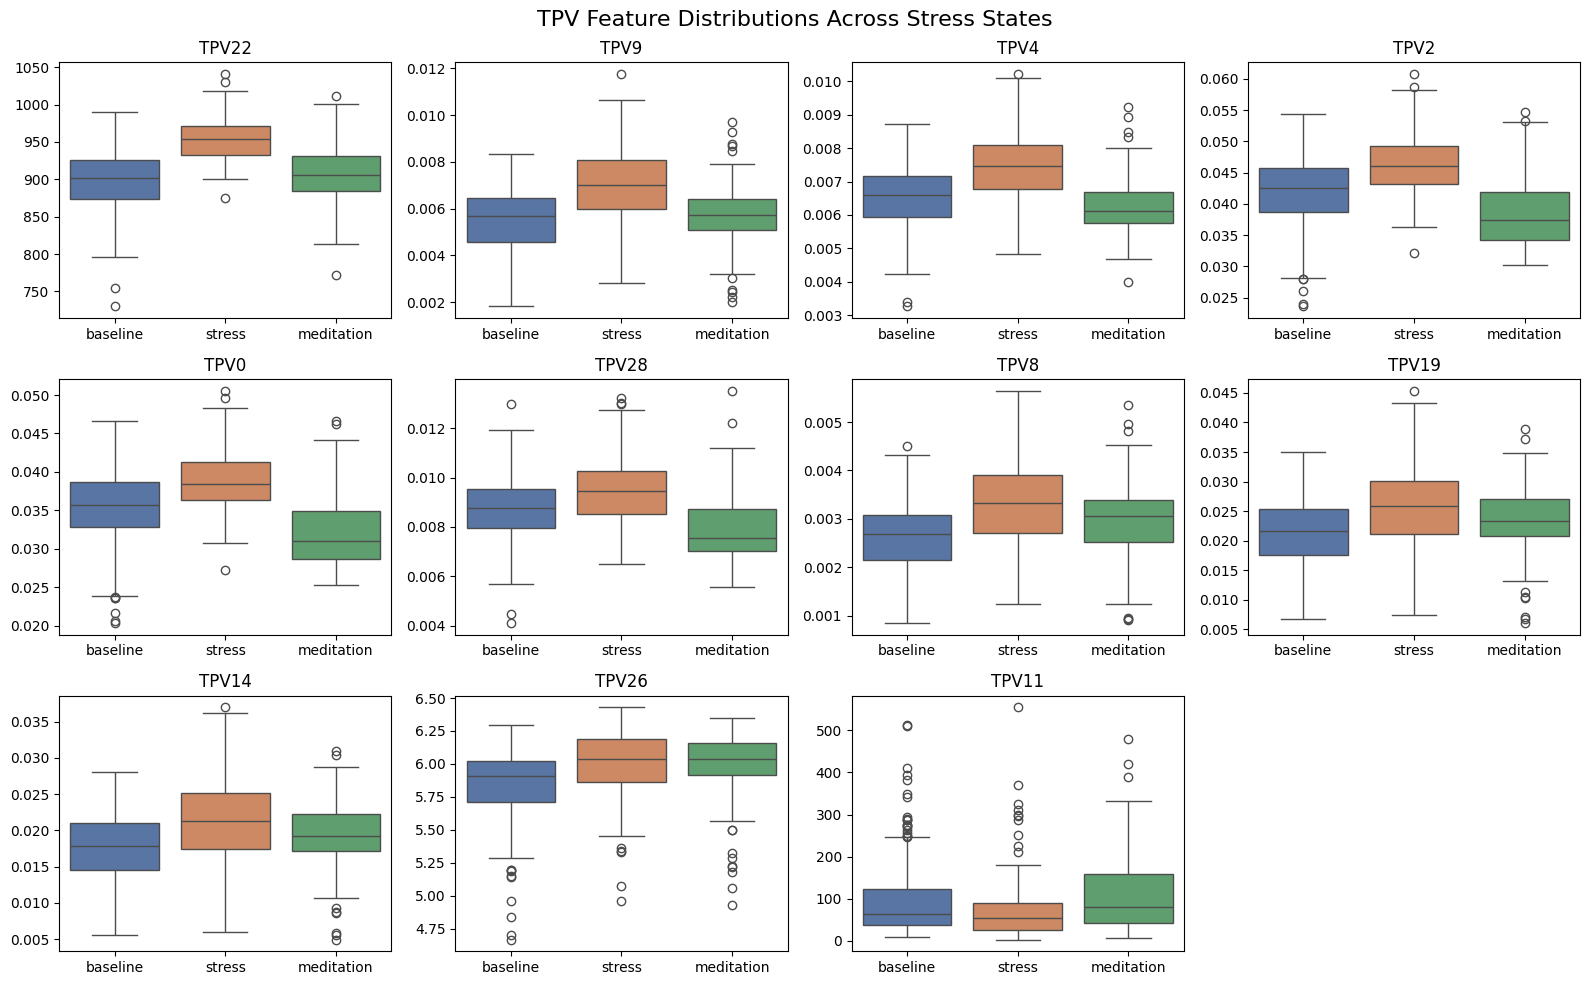


===== TPV Feature Summary =====
   feature Baseline (mean±std) Stress (mean±std) Meditation (mean±std)  \
0    TPV22    898.752 ± 40.577  953.796 ± 28.068      908.583 ± 44.817   
1     TPV9       0.006 ± 0.001     0.007 ± 0.002         0.006 ± 0.001   
2     TPV4       0.006 ± 0.001     0.007 ± 0.001         0.006 ± 0.001   
3     TPV2       0.042 ± 0.006     0.046 ± 0.005         0.039 ± 0.006   
4     TPV0       0.035 ± 0.005     0.039 ± 0.004         0.032 ± 0.005   
5    TPV28       0.009 ± 0.001     0.010 ± 0.001         0.008 ± 0.001   
6     TPV8       0.003 ± 0.001     0.003 ± 0.001         0.003 ± 0.001   
7    TPV19       0.021 ± 0.006     0.026 ± 0.007         0.023 ± 0.007   
8    TPV14       0.018 ± 0.005     0.021 ± 0.006         0.019 ± 0.005   
9    TPV26       5.839 ± 0.263     6.002 ± 0.255         5.966 ± 0.306   
10   TPV11     95.477 ± 83.731   76.029 ± 78.718      115.184 ± 98.120   

         anova_p  
0   5.158949e-39  
1   1.918014e-19  
2   3.132938e-22  
3 

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

# load
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BP/TPV-csv/noQC.csv")

# 상태 이름 정리
df["state"] = df["label_major"].map({
    1: "baseline",
    2: "stress",
    4: "meditation"
})

# TPV features
tpv_features = [
    'TPV22','TPV9','TPV4','TPV2','TPV0',
    'TPV28','TPV8','TPV19','TPV14','TPV26','TPV11'
]

results = []

# -------------------------
# Figure (11 boxplots)
# -------------------------

fig, axes = plt.subplots(3,4, figsize=(16,10))
axes = axes.flatten()

for i, feature in enumerate(tpv_features):

    data = df[["state",feature]].dropna()

    sns.boxplot(
        x="state",
        y=feature,
        data=data,
        ax=axes[i],
        palette=["#4C72B0","#DD8452","#55A868"]
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    # 통계
    b = data[data.state=="baseline"][feature]
    s = data[data.state=="stress"][feature]
    m = data[data.state=="meditation"][feature]

    anova = f_oneway(b,s,m)

    # mean std
    summary = data.groupby("state")[feature].agg(["mean","std"])

    results.append({
        "feature":feature,
        "baseline_mean":summary.loc["baseline","mean"],
        "baseline_std":summary.loc["baseline","std"],
        "stress_mean":summary.loc["stress","mean"],
        "stress_std":summary.loc["stress","std"],
        "med_mean":summary.loc["meditation","mean"],
        "med_std":summary.loc["meditation","std"],
        "anova_p":anova.pvalue
    })

# 마지막 subplot 제거 (12칸 중 11개 사용)
fig.delaxes(axes[-1])

plt.suptitle("TPV Feature Distributions Across Stress States", fontsize=16)

plt.tight_layout()
plt.show()

# -------------------------
# Table
# -------------------------

results_df = pd.DataFrame(results)

# mean±std 문자열로 정리
results_df["Baseline (mean±std)"] = results_df.apply(
    lambda r: f"{r['baseline_mean']:.3f} ± {r['baseline_std']:.3f}", axis=1)

results_df["Stress (mean±std)"] = results_df.apply(
    lambda r: f"{r['stress_mean']:.3f} ± {r['stress_std']:.3f}", axis=1)

results_df["Meditation (mean±std)"] = results_df.apply(
    lambda r: f"{r['med_mean']:.3f} ± {r['med_std']:.3f}", axis=1)

results_df = results_df[[
    "feature",
    "Baseline (mean±std)",
    "Stress (mean±std)",
    "Meditation (mean±std)",
    "anova_p"
]]

print("\n===== TPV Feature Summary =====")
print(results_df)

# EDA-TPV

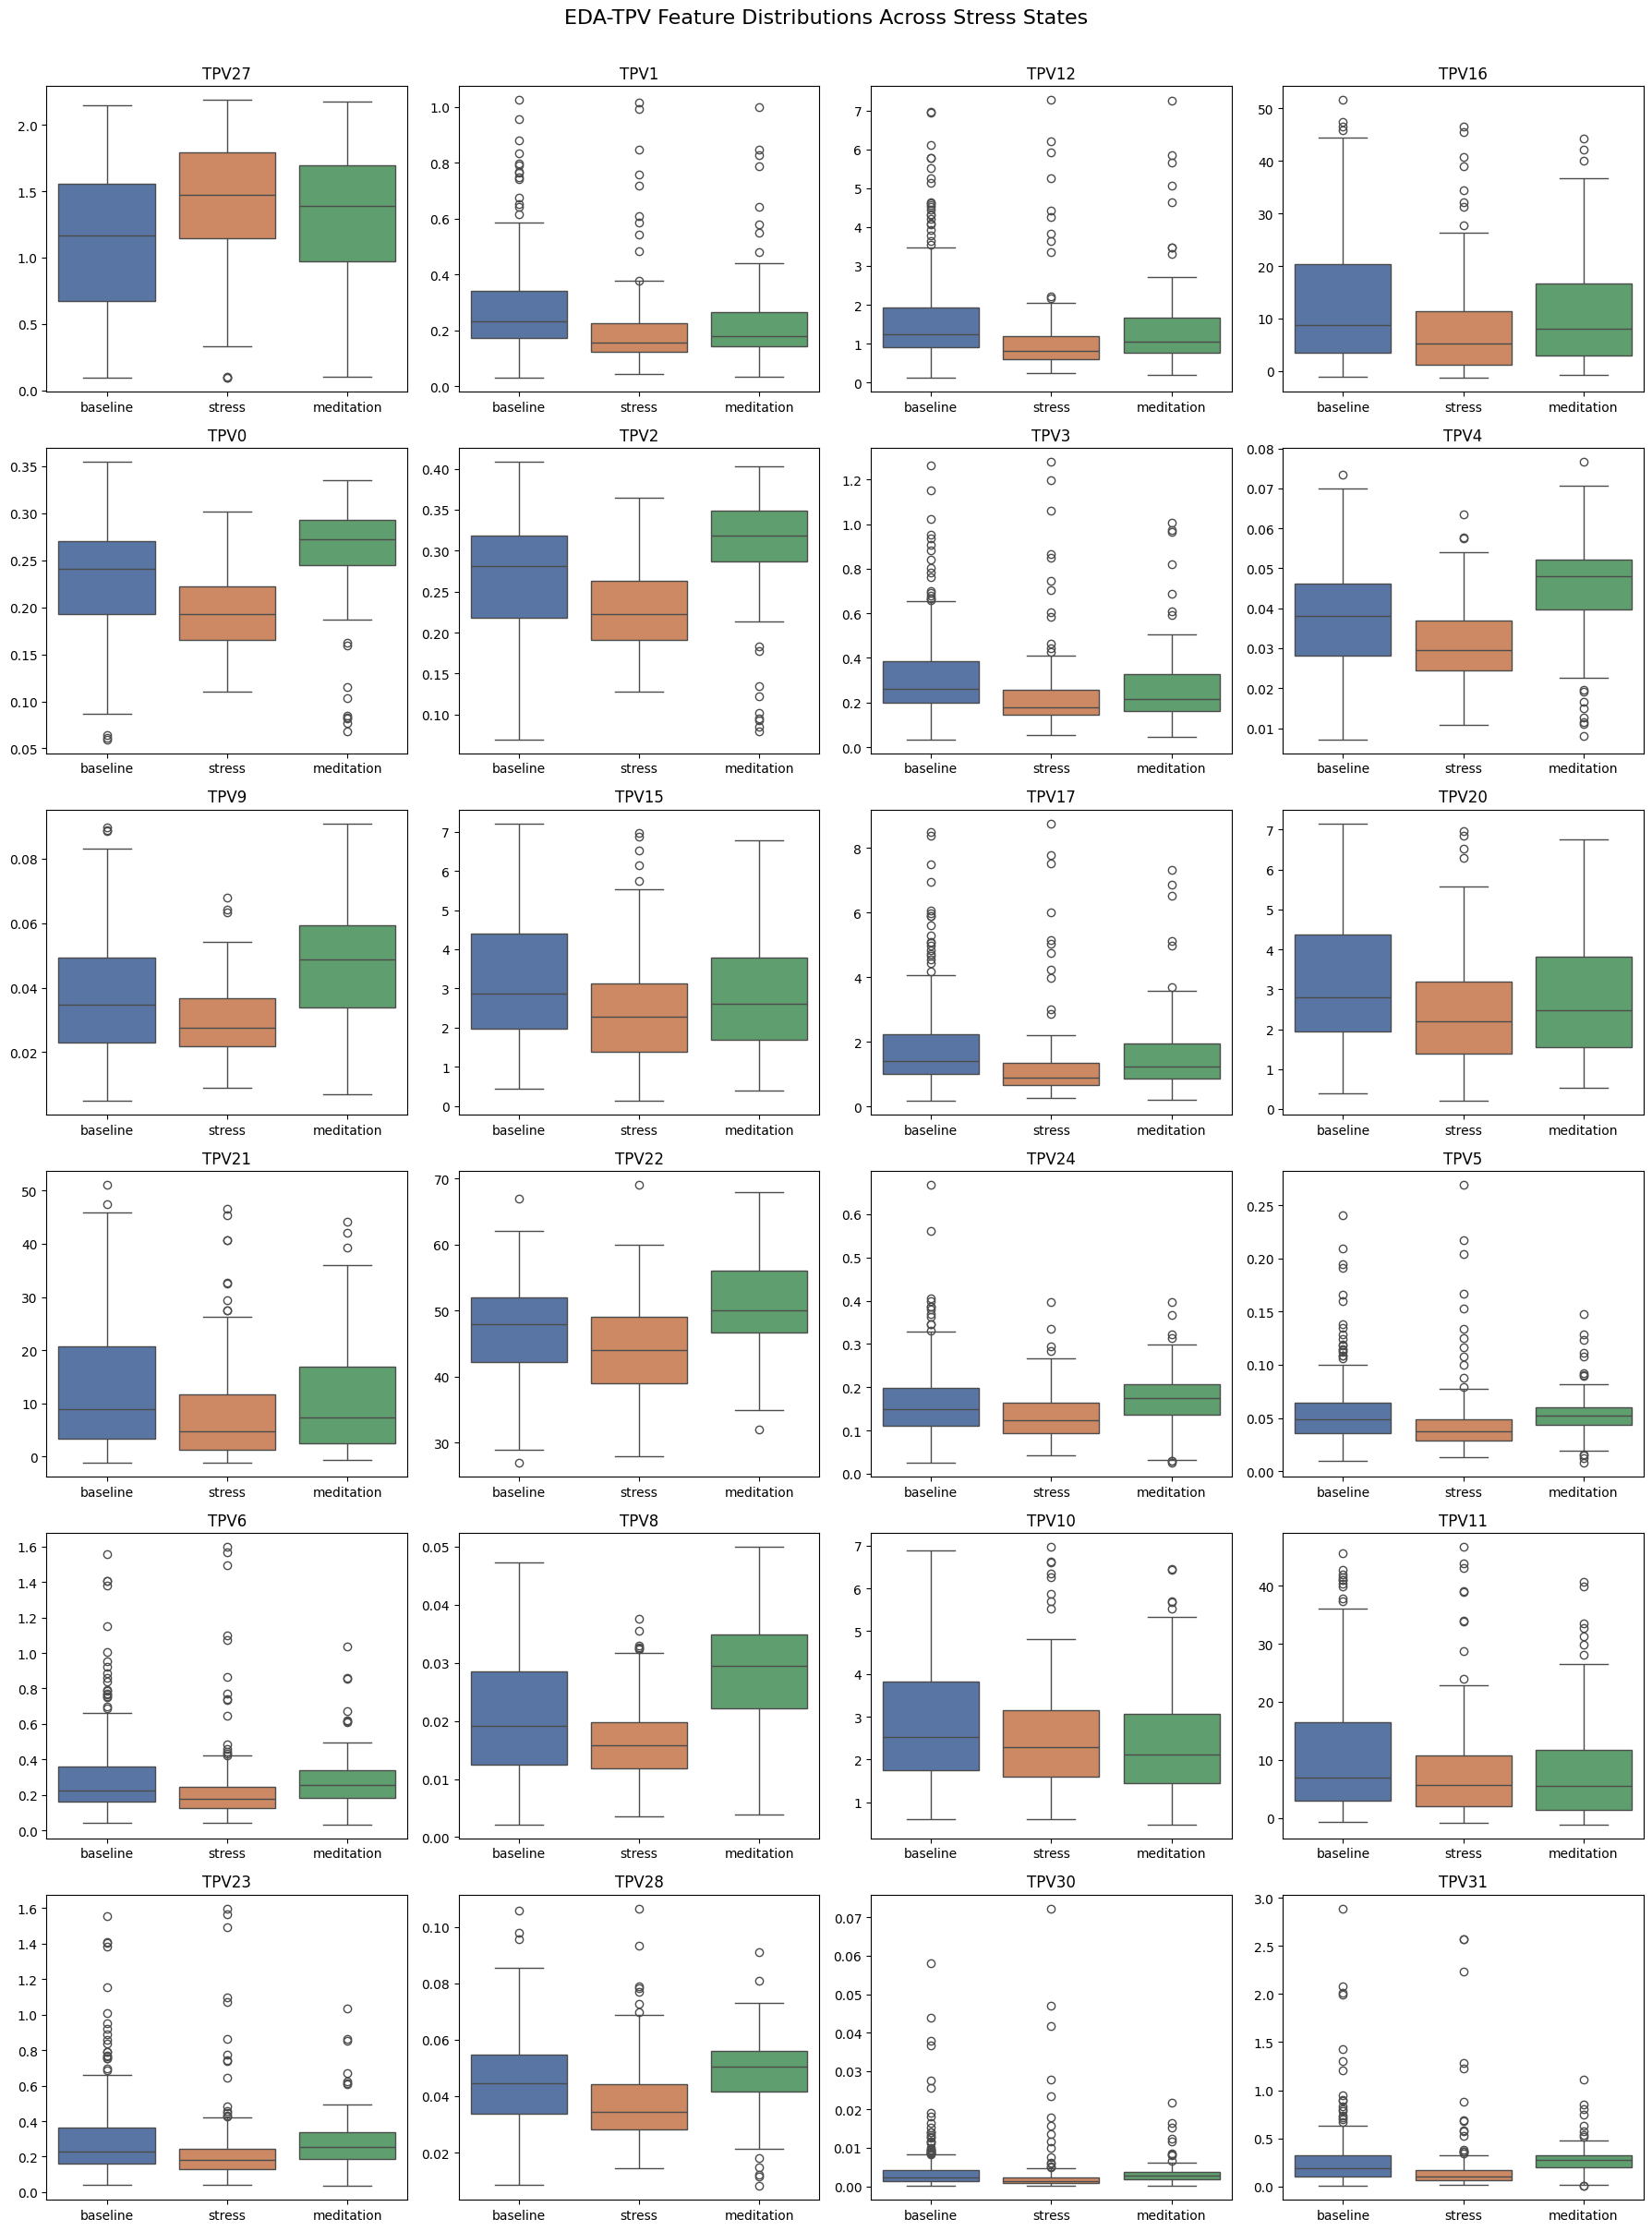


===== EDA-TPV Feature Summary =====
   feature Baseline (mean±std) Stress (mean±std) Meditation (mean±std)  \
0    TPV27       1.122 ± 0.518     1.405 ± 0.493         1.292 ± 0.547   
1     TPV1       0.280 ± 0.167     0.204 ± 0.156         0.246 ± 0.181   
2    TPV12       1.652 ± 1.193     1.126 ± 1.083         1.497 ± 1.278   
3    TPV16     13.154 ± 12.194     8.322 ± 9.686       11.316 ± 11.158   
4     TPV0       0.230 ± 0.061     0.197 ± 0.041         0.256 ± 0.062   
5     TPV2       0.267 ± 0.072     0.228 ± 0.049         0.300 ± 0.074   
6     TPV3       0.318 ± 0.190     0.235 ± 0.188         0.278 ± 0.195   
7     TPV4       0.037 ± 0.013     0.031 ± 0.010         0.044 ± 0.014   
8     TPV9       0.037 ± 0.018     0.030 ± 0.012         0.047 ± 0.020   
9    TPV15       3.190 ± 1.582     2.476 ± 1.418         2.884 ± 1.553   
10   TPV17       1.882 ± 1.365     1.299 ± 1.312         1.699 ± 1.378   
11   TPV20       3.154 ± 1.590     2.441 ± 1.414         2.822 ± 1.607   
1

In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

# load
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BP/TPV-csv/noQC_EDA.csv")

# 상태 이름 정리
df["state"] = df["label_major"].map({
    1: "baseline",
    2: "stress",
    4: "meditation"
})

# EDA-TPV features
tpv_features = [
    "TPV27", "TPV1", "TPV12", "TPV16", "TPV0", "TPV2", "TPV3", "TPV4",
    "TPV9", "TPV15", "TPV17", "TPV20", "TPV21", "TPV22", "TPV24", "TPV5",
    "TPV6", "TPV8", "TPV10", "TPV11", "TPV23", "TPV28", "TPV30", "TPV31"
]

results = []

# -------------------------
# Figure (24 boxplots)
# -------------------------
n_features = len(tpv_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(tpv_features):

    data = df[["state", feature]].dropna()

    sns.boxplot(
        x="state",
        y=feature,
        data=data,
        ax=axes[i],
        palette=["#4C72B0", "#DD8452", "#55A868"]
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    # 통계
    b = data[data["state"] == "baseline"][feature]
    s = data[data["state"] == "stress"][feature]
    m = data[data["state"] == "meditation"][feature]

    if len(b) > 0 and len(s) > 0 and len(m) > 0:
        anova = f_oneway(b, s, m)
        anova_p = anova.pvalue
    else:
        anova_p = float("nan")

    summary = data.groupby("state")[feature].agg(["mean", "std"])

    results.append({
        "feature": feature,
        "baseline_mean": summary.loc["baseline", "mean"] if "baseline" in summary.index else float("nan"),
        "baseline_std": summary.loc["baseline", "std"] if "baseline" in summary.index else float("nan"),
        "stress_mean": summary.loc["stress", "mean"] if "stress" in summary.index else float("nan"),
        "stress_std": summary.loc["stress", "std"] if "stress" in summary.index else float("nan"),
        "med_mean": summary.loc["meditation", "mean"] if "meditation" in summary.index else float("nan"),
        "med_std": summary.loc["meditation", "std"] if "meditation" in summary.index else float("nan"),
        "anova_p": anova_p
    })

# 남는 subplot 제거
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("EDA-TPV Feature Distributions Across Stress States", fontsize=16, y=1.005)
plt.tight_layout()
plt.show()

# -------------------------
# Table
# -------------------------
results_df = pd.DataFrame(results)

# mean±std 문자열로 정리
results_df["Baseline (mean±std)"] = results_df.apply(
    lambda r: f"{r['baseline_mean']:.3f} ± {r['baseline_std']:.3f}" if pd.notna(r["baseline_mean"]) else "nan",
    axis=1
)

results_df["Stress (mean±std)"] = results_df.apply(
    lambda r: f"{r['stress_mean']:.3f} ± {r['stress_std']:.3f}" if pd.notna(r["stress_mean"]) else "nan",
    axis=1
)

results_df["Meditation (mean±std)"] = results_df.apply(
    lambda r: f"{r['med_mean']:.3f} ± {r['med_std']:.3f}" if pd.notna(r["med_mean"]) else "nan",
    axis=1
)

results_df = results_df[[
    "feature",
    "Baseline (mean±std)",
    "Stress (mean±std)",
    "Meditation (mean±std)",
    "anova_p"
]]

print("\n===== EDA-TPV Feature Summary =====")
print(results_df)

# 필요하면 csv 저장
save_csv = "/content/drive/MyDrive/Colab Notebooks/BP/TPV-csv/EDA_TPV_feature_summary.csv"
results_df.to_csv(save_csv, index=False)
print(f"\n[INFO] Saved summary CSV: {save_csv}")